In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
fwhms = {}
import pickle
with open("saved_dict.pkl", "rb") as f:
    fwhms = pickle.load(f)

In [23]:
fwhms.keys()

dict_keys([-20000.0])

In [24]:
params = {}
with open("params1.txt") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params[item[0]] = float(item[1])
n0 = params['n0']
n2 = params['n2']
wavelength = params['wavelength'] / n0
w0 = params['w0']
print(w0)

0.0006773633813521525


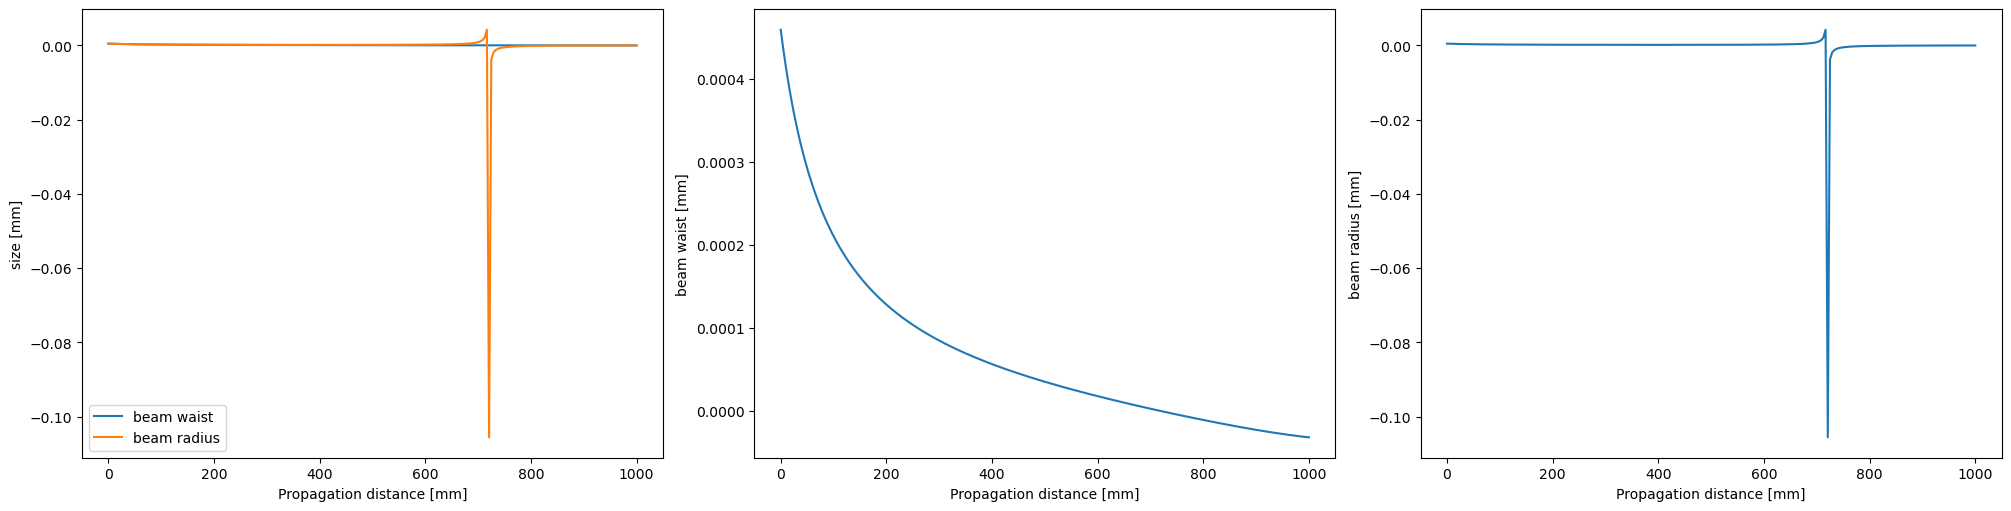

In [25]:
df = pd.read_csv("output.csv")
fig, axes = plt.subplots(1,3, figsize=(20,5), constrained_layout=True)

axes[0].plot(np.linspace(0, 1, df.index.size)*1000, df["beam waist"]*1000, label="beam waist")
axes[0].plot(np.linspace(0, 1, df.index.size)*1000, df["beam radius"]*1000, label="beam radius")
axes[0].set_ylabel("size [mm]")
axes[0].set_xlabel("Propagation distance [mm]")
axes[0].legend()

axes[1].plot(np.linspace(0, 1, df.index.size)*1000, df["beam waist"]*1000)
axes[1].set_ylabel("beam waist [mm]")
axes[1].set_xlabel("Propagation distance [mm]")

axes[2].plot(np.linspace(0, 1, df.index.size)*1000, df["beam radius"]*1000)
axes[2].set_ylabel("beam radius [mm]")
axes[2].set_xlabel("Propagation distance [mm]")

plt.show()

/tmp/ipykernel_14367/2646083436.py:15: RuntimeWarning: overflow encountered in square
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
/tmp/ipykernel_14367/2646083436.py:15: RuntimeWarning: overflow encountered in multiply
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
/tmp/ipykernel_14367/2646083436.py:15: RuntimeWarning: overflow encountered in exp
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
/tmp/ipykernel_14367/2646083436.py:15: RuntimeWarning: invalid value encountered in multiply
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D


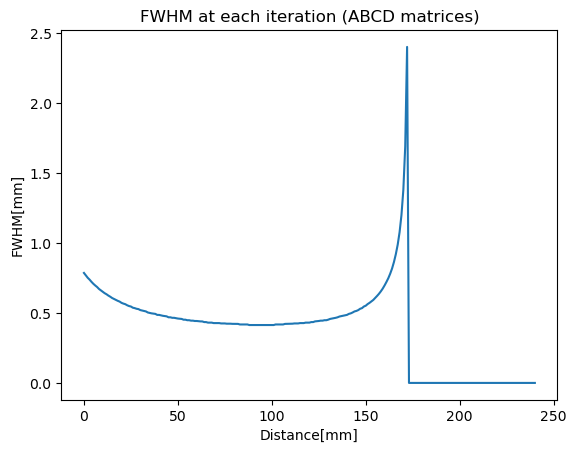

In [26]:
fwhm = []
length = pow(2,10)
width = 9000e-6
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
k = 2*np.pi / wavelength
# y = np.linspace(-width/2, width/2, length)
for i in range(0,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm.append((np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length) #return the difference (full width)
fwhm = np.array(fwhm)*1e3
plt.plot(np.arange(0, df.index.size, 1), fwhm)
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.title("FWHM at each iteration (ABCD matrices)")
plt.show()


/tmp/ipykernel_14367/2838069760.py:38: RuntimeWarning: invalid value encountered in scalar divide
  if np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp < 0.0001:
/tmp/ipykernel_14367/2838069760.py:14: RuntimeWarning: overflow encountered in square
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
/tmp/ipykernel_14367/2838069760.py:14: RuntimeWarning: overflow encountered in multiply
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
/tmp/ipykernel_14367/2838069760.py:14: RuntimeWarning: overflow encountered in exp
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
/tmp/ipykernel_14367/2838069760.py:14: RuntimeWarning: invalid value encountered in multiply
  Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D


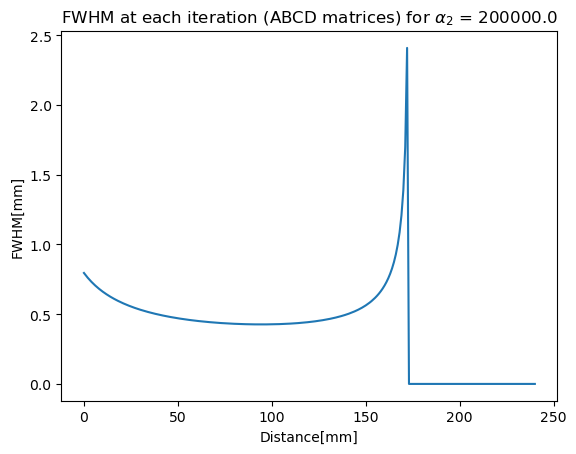

In [27]:
fwhm_refined = []
length = pow(2,10)
width = 9000e-6
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
# y = np.linspace(-width/2, width/2, length)
for i in range(0,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length
    fwhm_refined_temp = 1000
    for iter in range(10): 
        width_refined = 1.5*fwhm_temp
        x_refined = np.linspace(-width_refined/2, width_refined/2, length)
        y_refined = np.linspace(-width_refined/2, width_refined/2, length)
        xx_refined, yy_refined = np.meshgrid(x_refined,y_refined)
        Y = np.abs((1/(q)) * np.exp((-1j * k * (xx_refined*xx_refined + yy_refined*yy_refined)/(2*qr)) - (k*(xx_refined*xx_refined + yy_refined*yy_refined)/(2*qi))))**2
        half_max = np.max(Y) / 2.0
        maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
        left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
        fwhm_refined_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width_refined/length
        if np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp < 0.0001:
            # print(iter)
            break
        else:
            # print(iter, np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp)
            fwhm_temp = fwhm_refined_temp
            
    fwhm_refined.append(fwhm_refined_temp) #return the difference (full width)
fwhm_refined = np.array(fwhm_refined)*1e3
plt.plot(np.arange(0, df.index.size, 1), fwhm_refined)
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.title(f"FWHM at each iteration (ABCD matrices) for $\\alpha_2$ = {params["a2"]}")
plt.show()


In [28]:
fwhms[params["a2"]] = fwhm_refined.copy()

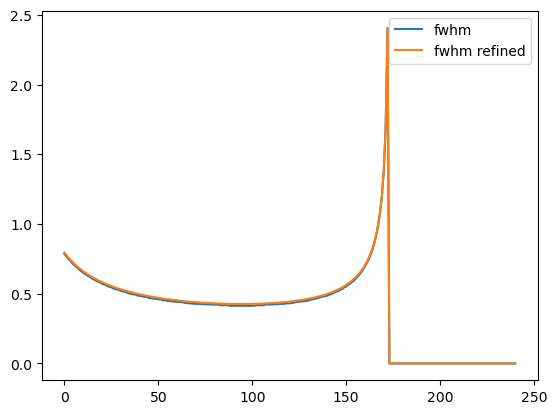

In [29]:
plt.plot(fwhm, label='fwhm')
plt.plot(fwhm_refined, label='fwhm refined')
plt.legend()
plt.show()

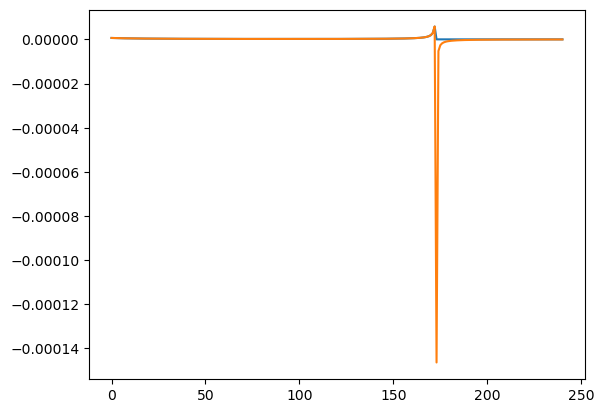

In [30]:
plt.plot((fwhm_refined/1e3)**2)
plt.plot(df["beam radius"]*(-2*np.log(0.5)))
plt.show()

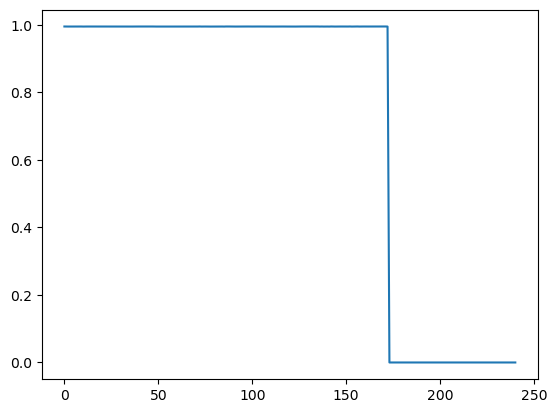

In [31]:
plt.plot((fwhm_refined/1e3)**2 / (df["beam radius"]*(-2*np.log(0.5))))
plt.show()

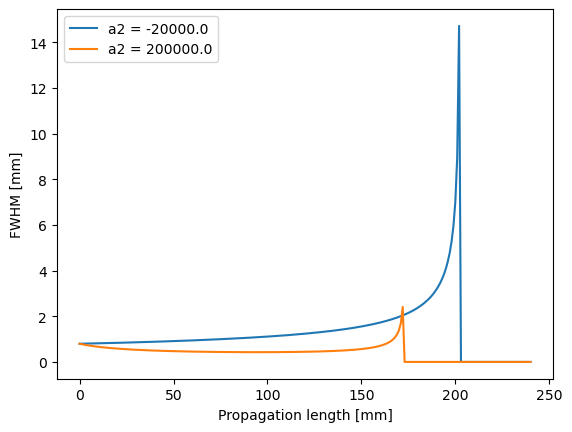

In [32]:
for key in sorted(fwhms.keys()):
    plt.plot(fwhms[key], label=f"a2 = {key}")
plt.xlabel("Propagation length [mm]")
plt.ylabel("FWHM [mm]")
plt.legend()
plt.show()

In [22]:
fwhms.pop(1.5e5)

array([0.79551796, 0.78217332, 0.7695092 , 0.75752607, 0.74609495,
       0.73519233, 0.72489342, 0.71493426, 0.70553924, 0.69649349,
       0.6878088 , 0.67945226, 0.67151966, 0.6638258 , 0.65644762,
       0.64938271, 0.64249139, 0.63595769, 0.62955604, 0.62346731,
       0.617536  , 0.61177098, 0.60628796, 0.60087555, 0.59570647,
       0.5906897 , 0.58583027, 0.58105176, 0.57652176, 0.57206956,
       0.56770052, 0.56349124, 0.55948213, 0.55550374, 0.55166596,
       0.54790922, 0.54421831, 0.54069617, 0.53723042, 0.53384101,
       0.53057011, 0.5273679 , 0.52427735, 0.52125032, 0.51827912,
       0.51534552, 0.51257049, 0.50983616, 0.50714294, 0.50448106,
       0.50192994, 0.49942282, 0.49695497, 0.49458558, 0.49223765,
       0.48996236, 0.48773736, 0.48552664, 0.48339345, 0.48133173,
       0.47930086, 0.47727771, 0.47535367, 0.47341785, 0.4715608 ,
       0.46974282, 0.467954  , 0.46616248, 0.46449036, 0.46281913,
       0.46115907, 0.45953565, 0.45798955, 0.45645689, 0.45489

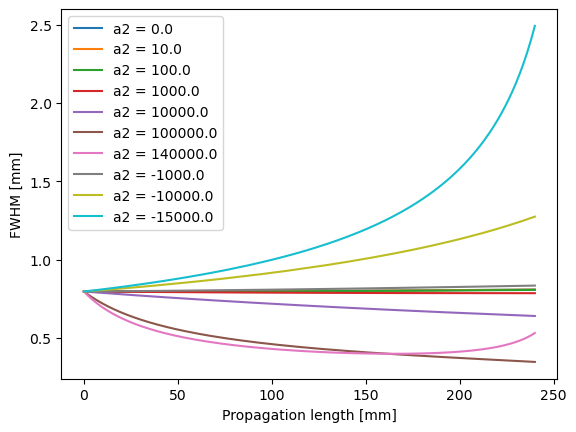

In [109]:
import pickle

with open("saved_dict.pkl", "wb") as f:
    pickle.dump(fwhms, f)
with open("saved_dict.pkl", "rb") as f:
    load_dict = pickle.load(f)
    for key in load_dict.keys():
        plt.plot(load_dict[key], label=f"a2 = {key}")
    plt.xlabel("Propagation length [mm]")
    plt.ylabel("FWHM [mm]")
    plt.legend()
    plt.show()

In [20]:
mape = {}
smape = {}
mae = {}
maxPE = {}

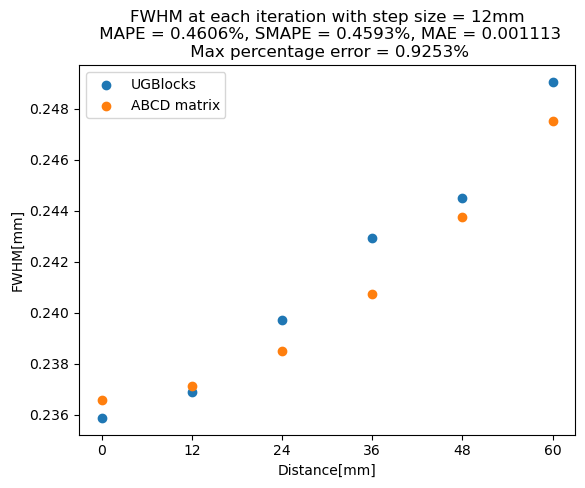

In [64]:
# fwhm_ugb = np.array([0.0820841,0.121976,0.166244,0.203626,0.243607,0.285258,0.328429,0.368583,0.409361,0.450372,0.49066])
# fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhm.csv', delimiter=',', dtype=float)
fwhm_ugb = np.loadtxt('/home/karthik/FAUbox/thesis/fwhm.csv', delimiter=',', dtype=float)
# file = open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat", 'r')
file = open("/home/karthik/FAUbox/thesis/para.dat", 'r')
params_ugb = list(map(float, file.read().split()))
end = params["propagation_length"]*(params["iterations"]+1) * 1000
# step = params["propagation_length"] * 1000
step = int(params_ugb[2])
plt.scatter(np.arange(0, end, step), fwhm_ugb[0::1], label="UGBlocks")
plt.scatter(np.arange(0, end, step), fwhm_refined[0::step], label="ABCD matrix")
mape[step] = 100 * np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]) / fwhm_refined[0::step])
smape[step] = 200 * np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]) / (np.abs(fwhm_ugb) + np.abs(fwhm_refined[0::step])))
mae[step] = np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]))
maxPE[step] = 100 * np.max(np.abs(fwhm_ugb - fwhm_refined[0::step]) / fwhm_refined[0::step])
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.xticks(np.arange(0, end, step))
plt.title(f"FWHM at each iteration with step size = {step}mm\n MAPE = {mape[step]:.4f}%, SMAPE = {smape[step]:.4f}%, MAE = {mae[step]:.6f}\n Max percentage error = {maxPE[step]:.4f}%")
plt.legend()
plt.show()

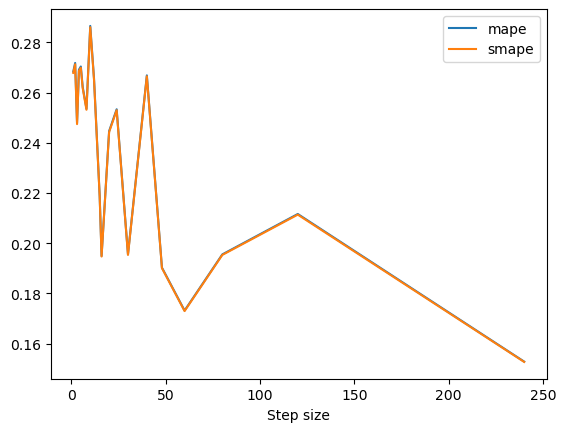

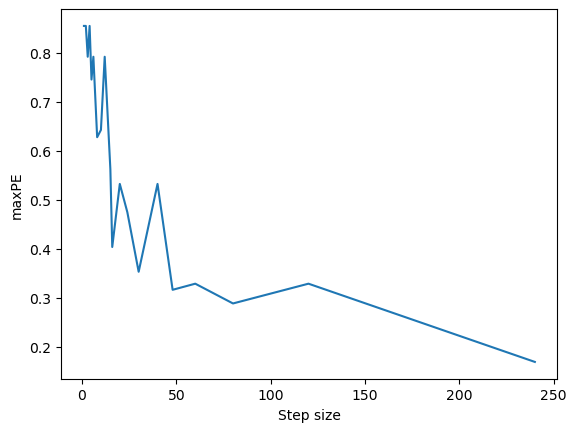

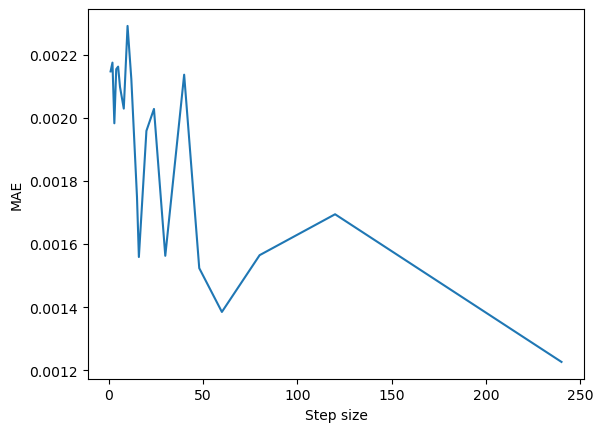

In [229]:
lists = sorted(mape.items())
x, y = zip(*lists)
plt.plot(x, y, label = "mape")
lists = sorted(smape.items())
x, y = zip(*lists)
plt.plot(x, y, label = "smape")
plt.legend()
plt.xlabel("Step size")
plt.show()

lists = sorted(maxPE.items())
x, y = zip(*lists)
plt.plot(x, y)
plt.xlabel("Step size")
plt.ylabel("maxPE")
plt.show()

lists = sorted(mae.items())
x, y = zip(*lists)
plt.plot(x, y)
plt.xlabel("Step size")
plt.ylabel("MAE")
plt.show()